# Analyze results from phyloglm

In [29]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

results_path = os.path.join(repo_root, "results")

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
pglm_df = pd.read_csv(f"{results_path}/phyloglm/phyloglm_qvals.csv", index_col="HOG")

In [31]:
sig_pglm = pglm_df[pglm_df["qvalue"] < 0.05].sort_values("qvalue")

print("Significant HOGs by PhyloGLM:", sig_pglm.shape[0])

Significant HOGs by PhyloGLM: 897


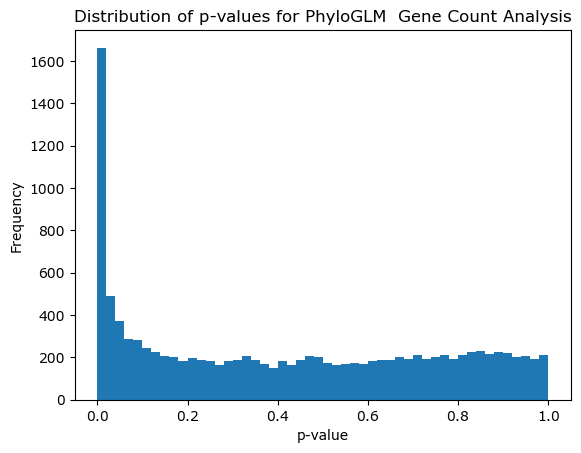

In [32]:
plt.hist(pglm_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM  Gene Count Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

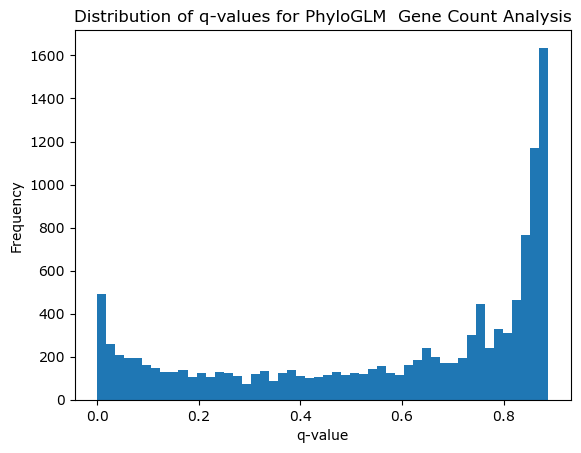

In [33]:
plt.hist(pglm_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM  Gene Count Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

### Investigate overlap with log odds ratio permulation test

In [34]:
loss_res_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/perm_loss_pvalues.csv", index_col="HOG")
dup_res_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/perm_dup_pvalues.csv", index_col="HOG")

In [35]:
all_sig_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/fltrd_hits.csv", index_col="HOG")

In [36]:
loss_fg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("loss_fg", na=False)]
loss_bg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("loss_bg", na=False)]
dup_fg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("dup_fg", na=False)]
dup_bg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("dup_bg", na=False)]

print("Loss Foreground Significant by Permulation:", loss_fg_sig_perm.shape[0])
print("Loss Background Significant by Permulation:", loss_bg_sig_perm.shape[0])
print("Duplicate Foreground Significant by Permulation:", dup_fg_sig_perm.shape[0])
print("Duplicate Background Significant by Permulation:", dup_bg_sig_perm.shape[0])

Loss Foreground Significant by Permulation: 224
Loss Background Significant by Permulation: 529
Duplicate Foreground Significant by Permulation: 429
Duplicate Background Significant by Permulation: 383


In [37]:
loss_fg_sig_perm_thresh = loss_fg_sig_perm[loss_fg_sig_perm["Significant by avgd thresholds"].str.contains("loss_fg", na=False)].shape[0]
loss_bg_sig_perm_thresh = loss_bg_sig_perm[loss_bg_sig_perm["Significant by avgd thresholds"].str.contains("loss_bg", na=False)].shape[0]
dup_fg_sig_perm_thresh = dup_fg_sig_perm[dup_fg_sig_perm["Significant by avgd thresholds"].str.contains("dup_fg", na=False)].shape[0]
dup_bg_sig_perm_thresh = dup_bg_sig_perm[dup_bg_sig_perm["Significant by avgd thresholds"].str.contains("dup_bg", na=False)].shape[0]

print("Loss Foreground Significant by Permulation and Thresholds:", loss_fg_sig_perm_thresh)
print("Loss Background Significant by Permulation and Thresholds:", loss_bg_sig_perm_thresh)
print("Duplicate Foreground Significant by Permulation and Thresholds:", dup_fg_sig_perm_thresh)
print("Duplicate Background Significant by Permulation and Thresholds:", dup_bg_sig_perm_thresh)


Loss Foreground Significant by Permulation and Thresholds: 52
Loss Background Significant by Permulation and Thresholds: 217
Duplicate Foreground Significant by Permulation and Thresholds: 141
Duplicate Background Significant by Permulation and Thresholds: 86


In [38]:
sig_pglm_orb = sig_pglm[sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
sig_pglm_nonorb = sig_pglm[sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]
print("Foreground Significant by PhyloGLM:", sig_pglm_orb.shape[0])
print("Background Significant by PhyloGLM:", sig_pglm_nonorb.shape[0])

Foreground Significant by PhyloGLM: 526
Background Significant by PhyloGLM: 371


In [39]:
overlap_loss_fg_df = loss_fg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_loss_bg_df = loss_bg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_fg_df = dup_fg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_bg_df = dup_bg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))

print("Overlap Loss Foreground Significant by Both:", overlap_loss_fg_df.shape[0])
print("Overlap Loss Background Significant by Both:", overlap_loss_bg_df.shape[0])
print("Overlap Duplication Foreground Significant by Both:", overlap_dup_fg_df.shape[0])
print("Overlap Duplication Background Significant by Both:", overlap_dup_bg_df.shape[0])

Overlap Loss Foreground Significant by Both: 22
Overlap Loss Background Significant by Both: 56
Overlap Duplication Foreground Significant by Both: 71
Overlap Duplication Background Significant by Both: 81


In [40]:
overlap_all_df = all_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_all_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation,error,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,qvalue
HOG,,,,,,,,,,,,,,,,,,,
N5.HOG0002298,30,-2.467858,1.155650,0.9909,0.0091,0.3621,0.6379,NaN,loss_bg,NaN,-1.719616,0.606574,-2.834967,0.004583,1.402103,0.407769,3.438473,0.000585,0.014122
N5.HOG0007085,78,-2.727537,-0.768582,0.9976,0.0024,0.7169,0.2831,NaN,loss_bg,NaN,-0.197156,0.318790,-0.618450,0.536279,0.607532,0.199406,3.046710,0.002314,0.033634
N5.HOG0007270,32,-2.655932,1.114187,0.9873,0.0127,0.3956,0.6044,NaN,loss_bg,NaN,-1.510297,0.656950,-2.298954,0.021508,1.506462,0.448481,3.359029,0.000782,0.017210
N5.HOG0007311,35,1.441096,-2.394613,0.0053,0.9947,0.9401,0.0599,NaN,loss_fg,NaN,-0.007673,0.305494,-0.025118,0.979961,-1.254252,0.422571,-2.968141,0.002996,0.039866
N5.HOG0007702,42,-2.870699,3.593198,0.9471,0.0529,0.0123,0.9877,dup_fg,dup_fg,NaN,-1.154932,0.454522,-2.540980,0.011054,0.998130,0.304527,3.277636,0.001047,0.020441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N5.HOG0071249,61,-2.992514,0.210530,0.9991,0.0009,0.3327,0.6671,loss_bg,loss_bg,NaN,-1.187833,0.512868,-2.316060,0.020555,0.966563,0.326275,2.962413,0.003052,0.040411
N5.HOG0071605,41,-1.494884,1.914310,0.9294,0.0706,0.0493,0.9507,NaN,dup_fg,NaN,-1.209264,0.662527,-1.825229,0.067966,1.392878,0.444787,3.131564,0.001739,0.028373
N5.HOG0071908,39,-1.683040,2.289244,0.9778,0.0222,0.0387,0.9613,", dup_fg","loss_bg, dup_fg",NaN,-0.562326,0.394157,-1.426654,0.153680,0.709980,0.246703,2.877875,0.004004,0.048074
